## imports

In [122]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [123]:

from ult import *
import multiprocess
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2


# use new data

In [124]:
modelnamefull='seed_0_varyrewardpv2_epoch_10'
# modelname = 'varyrewardperoid2'
# thismodel = f'seed_{seed}_{modelname}_{modeli}'

# training hyper params
epoch_size = 33333
n_epoch = 22
n_seed = 1
modeli = 0
plot_no_episodes = 333

no_episodes = 2222
epochtouse = 8

attcost = -1.6
facost = -50
p1p2 = np.array([.5, .7])
seed = 0
np.random.seed(seed)

vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
env_param = [0, None, attcost, .25, facost, 0, 0]


task = AFR2(spec={'agent': {'lick_cost': env_param[0],
                            'food_reward': env_param[1],
                            'attention_cost_coeff': env_param[2],
                            'attention_cost_temp': env_param[3],
                            'penalty_cost': env_param[4],
                            'iti_cost': env_param[5],
                            'time_in_game_reward': env_param[6]}})
task.food_reward_list = food_reward_list
taskbelief = FuncBeliefModel(env=task, rng=1)
task.obs_certainity_possible = p1p2
# model = PPO.load(f'ycstore/{ thismodel}_epoch_{epochtouse}')
# print(f'ycstore/{thismodel}_epoch_{epochtouse}')
model=PPO.load(f'ycstore/{modelnamefull}')


In [125]:
# # collect trial data
# def eval_wrapper(a):
#     episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
#                               num_steps=100000, deterministic=True)
#     return episode


# with multiprocess.Pool(processes=6) as pool:
#     all_episode_data = pool.map(eval_wrapper, range(no_episodes))

# use figdata

In [126]:
# save_pickle_file('figdata/peroid.pkl', all_episode_data)
all_episode_data = open_pickle_file('figdata/peroid.pkl')

In [127]:
# process the data.
all_reward_res={} # k: v = foodreward idx: this food reward res
for r in range(len(food_reward_list)):
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
    all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len


for episode in all_episode_data[:]:
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
    att_time_list.append(
        np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
 
    if episode['actions'][-1][0] == 1:
        lick_time_list.append(len(episode['states']))
    else:
        lick_time_list.append(None)
    trial_len.append(len(episode['actions']))

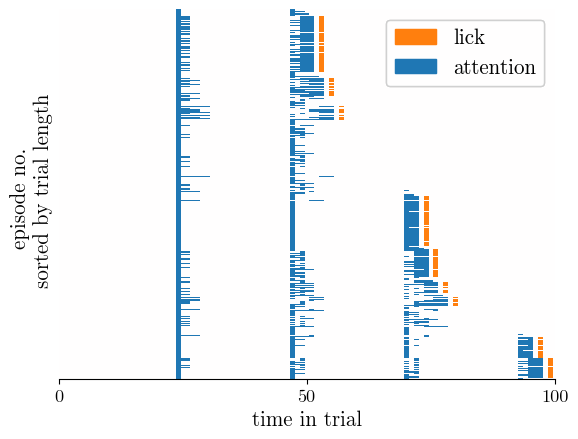

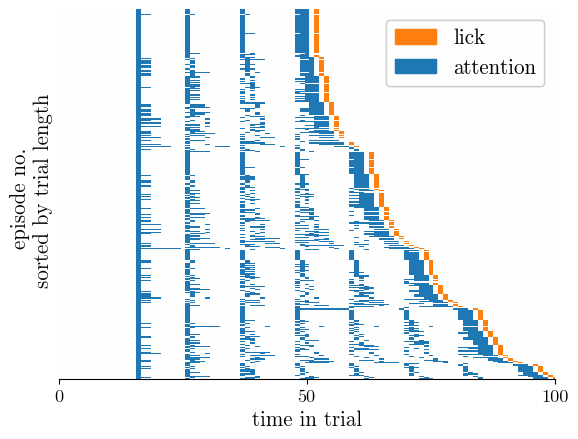

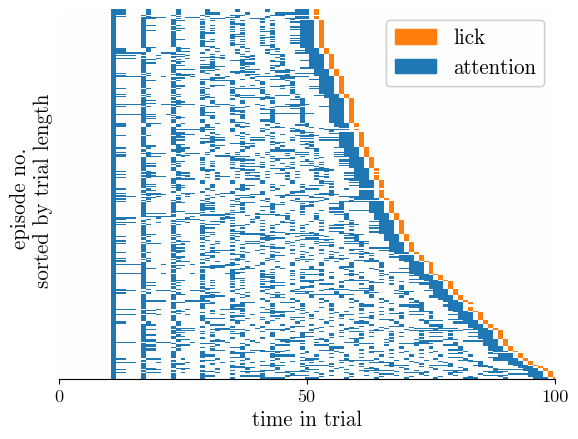

In [140]:
# heatmap trial indicator (att and lick) new, select len
minlen, maxlen = 50, 100

for food_reward_idx in (all_reward_res.keys()):
    attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
        food_reward_idx]
    trial_len = np.array(trial_len)
    valid_ind = np.where((minlen < trial_len) & (trial_len < maxlen))[0]
    grid = np.zeros((len(valid_ind), max(trial_len)+2))

    sortind = np.argsort([trial_len[i] for i in valid_ind])
    valid_ind = valid_ind[sortind]

    # att
    plot_data = [att_time_list[i] for i in valid_ind]
    for i, arr in enumerate(plot_data):
        grid[i, arr] = -1

    # lick
    plot_data = [lick_time_list[i] for i in valid_ind]
    for i, arr in enumerate(plot_data):
        if arr:
            grid[i, arr] = 1
    if np.sum(grid) == 0:
        continue
    fig=plt.figure()

    colors = [attn_color, 'white', lick_color]
    stops = [0.0, 0.5, 1.0]
    attnlickcmap = LinearSegmentedColormap.from_list(
        'custom_cmap', list(zip(stops, colors)))

    c = plt.imshow(grid, cmap=attnlickcmap, vmin=-1, vmax=1,
                   aspect='auto', interpolation='none')

    plt.xticks([0, 50, 100])
    plt.xlim(0, 100)
    plt.yticks([])
    ax = plt.gca()
    ax.spines['left'].set_visible(False)
    plt.xlabel('time in trial')
    plt.ylabel('episode no. \n sorted by trial length')
    # plt.title(f'attn, food reward: {food_reward_list[food_reward_idx]}')

    lickdot = Patch(color=lick_color, label='lick')
    attdot = Patch(color=attn_color, label='attention')
    extra_legend = plt.legend(
        handles=[lickdot, attdot], bbox_to_anchor=(1, 1), frameon=True)
    ax.add_artist(extra_legend)
    # quickleg(ax)

    ax.add_artist(extra_legend)
    with plt.rc_context({'image.composite_image': False}):
        fig.savefig(f'fig/plot p/attn lick raster {food_reward_idx}.svg')
    plt.show()

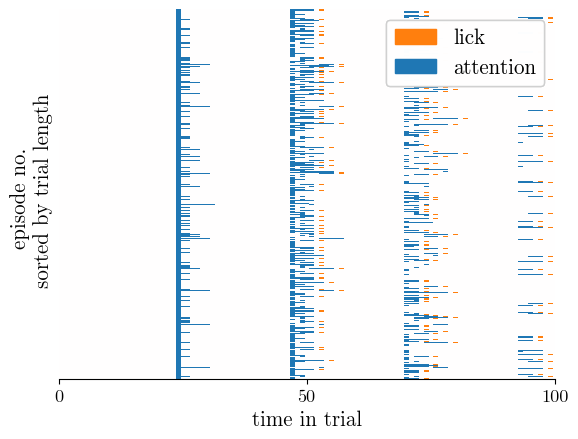

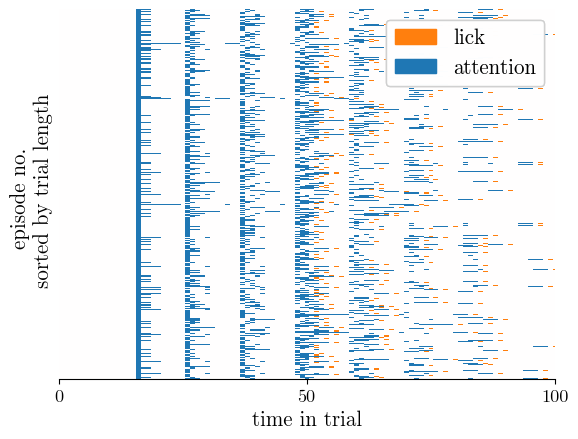

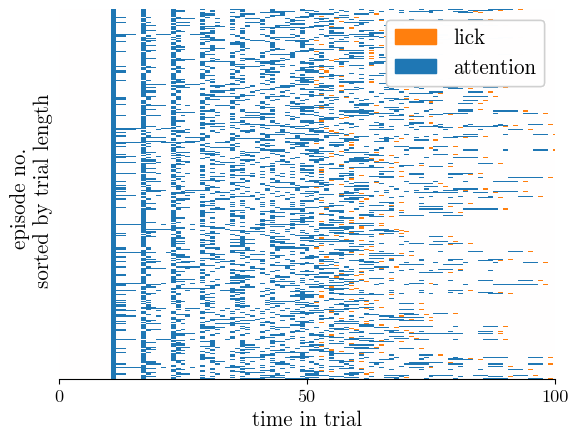

In [142]:
# heatmap trial indicator (att and lick) new, select len
minlen, maxlen = 50, 100

for food_reward_idx in (all_reward_res.keys()):
    attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
        food_reward_idx]
    trial_len = np.array(trial_len)
    valid_ind = np.where((minlen < trial_len) & (trial_len < maxlen))[0]
    grid = np.zeros((len(valid_ind), max(trial_len)+2))

    # att
    plot_data = [att_time_list[i] for i in valid_ind]
    for i, arr in enumerate(plot_data):
        grid[i, arr] = -1

    # lick
    plot_data = [lick_time_list[i] for i in valid_ind]
    for i, arr in enumerate(plot_data):
        if arr:
            grid[i, arr] = 1
    if np.sum(grid) == 0:
        continue
    fig=plt.figure()

    colors = [attn_color, 'white', lick_color]
    stops = [0.0, 0.5, 1.0]
    attnlickcmap = LinearSegmentedColormap.from_list(
        'custom_cmap', list(zip(stops, colors)))

    c = plt.imshow(grid, cmap=attnlickcmap, vmin=-1, vmax=1,
                   aspect='auto', interpolation='none')

    plt.xticks([0, 50, 100])
    plt.xlim(0, 100)
    plt.yticks([])
    ax = plt.gca()
    ax.spines['left'].set_visible(False)
    plt.xlabel('time in trial')
    plt.ylabel('episode no. \n sorted by trial length')
    # plt.title(f'attn, food reward: {food_reward_list[food_reward_idx]}')

    lickdot = Patch(color=lick_color, label='lick')
    attdot = Patch(color=attn_color, label='attention')
    extra_legend = plt.legend(
        handles=[lickdot, attdot], bbox_to_anchor=(1, 1), frameon=True)
    ax.add_artist(extra_legend)
    # quickleg(ax)

    ax.add_artist(extra_legend)


    with plt.rc_context({'image.composite_image': False}):
        fig.savefig(f'fig/plot p/attn lick raster {food_reward_idx} unsorted.svg')
    plt.show()


webf NOT subset; don't know how to subset; dropped


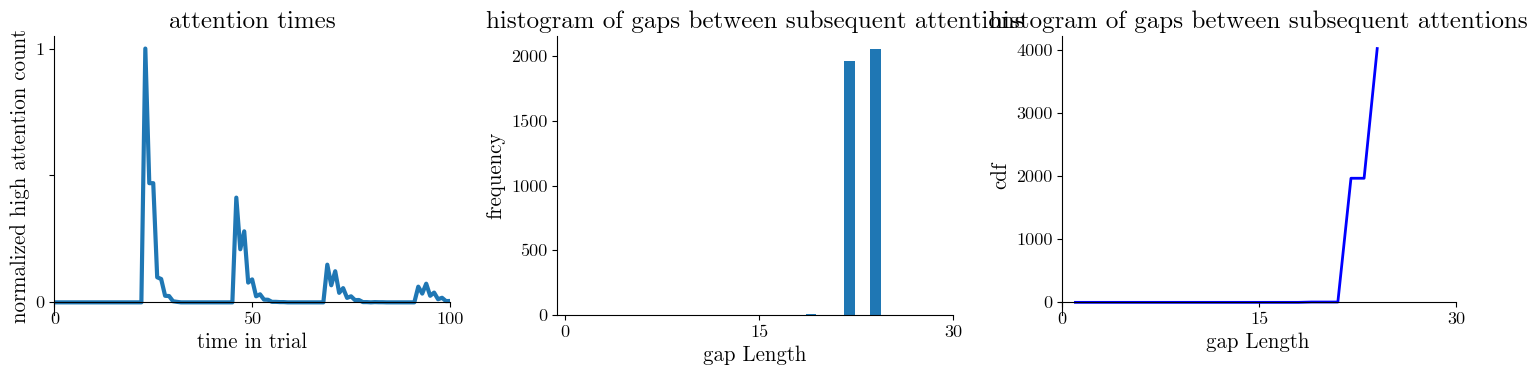

webf NOT subset; don't know how to subset; dropped


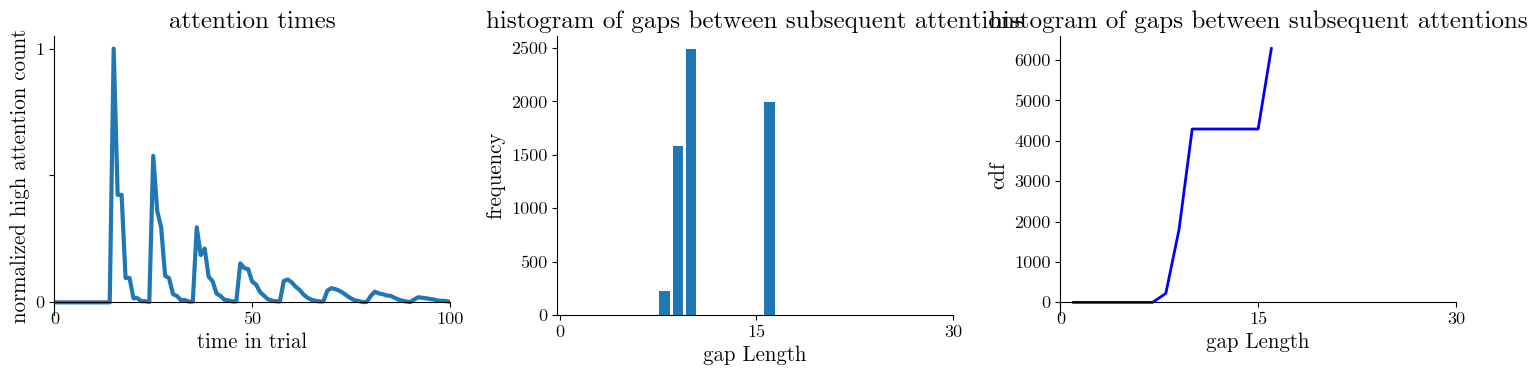

webf NOT subset; don't know how to subset; dropped


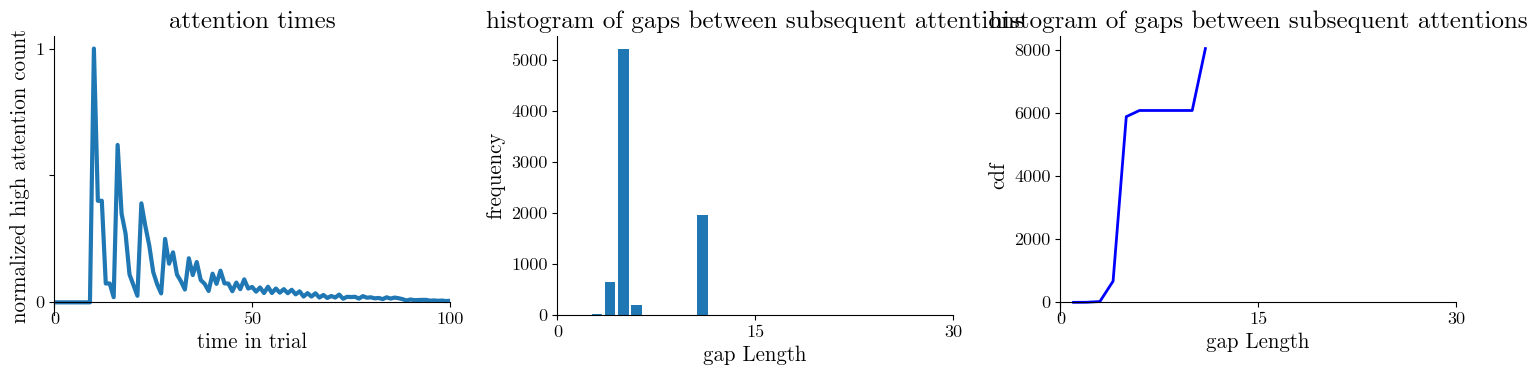

In [145]:
# att time
for food_reward_idx in (all_reward_res.keys()):
    attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
        food_reward_idx]
    title = f'reward: {food_reward_list[food_reward_idx]:.0f}'
    if len(att_time_list[0]) > 0:

        data = att_time_list
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
        plotdata = np.sum(pad_zero_attention(data), axis=0)/len(data)
        plotdata = plotdata[1:]  # remove the first iti state
        ax1.plot(plotdata, linewidth=3)
        ax1.set_xlabel('time in trial')
        ax1.set_ylabel('normalized high attention count')
        ax1.set_title('attention times')
        centerax(ax1)
        ax1.set_xticks([0, 50, 100])
        ax1.set_yticks([0, 0.5, 1], ['0', '', '1'])
        ax1.set_xlim(0, 100)

        histogram = gap_histogram_all_rows(pad_zero_attention(data))
        # sns.kdeplot(histogram[0], color='red',bw_adjust=.1)

        ax2.bar(histogram[1][:-1], histogram[0], width=0.8, align='center')
        ax2.set_xticks([0, 15, 30])
        ax2.set_xlabel('gap Length')
        ax2.set_ylabel('frequency')
        ax2.set_title(f'histogram of gaps between subsequent attentions')

        counts, bins = gap_histogram_all_rows(pad_zero_attention(data))
        bin_width = bins[1] - bins[0]

        counts, bins = gap_histogram_all_rows(pad_zero_attention(data))
        bin_width = bins[1] - bins[0]
        pdf = counts / (np.sum(counts) * bin_width)
        cdf = np.cumsum(counts) * bin_width
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(cdf)
        smoothed_cdf = kde.integrate_box_1d(-np.inf, bins[:-1])
        # ax3.plot(bins[:-1], pdf, color='red', linestyle='-', linewidth=2, label='PDF')
        ax3.plot(bins[:-1], cdf, color='blue',
                 linestyle='-', linewidth=2, label='cdf')
        ax3.set_xlabel('gap Length')
        ax3.set_ylabel('cdf')
        centerax(ax3)
        ax3.set_xticks([0, 15, 30])
        ax3.set_title(f'histogram of gaps between subsequent attentions')

        # plt.suptitle(title)
        plt.tight_layout()
        quicksave(f'att time, gap, cdf {food_reward_idx}', 'plot p')
        plt.show()

webf NOT subset; don't know how to subset; dropped


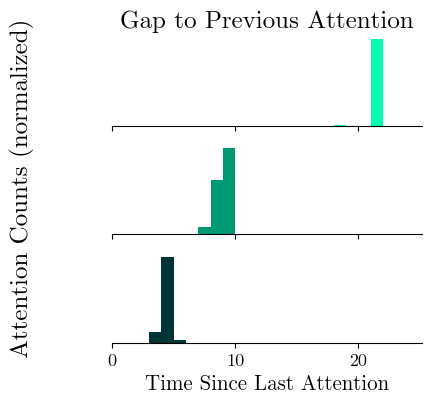

In [147]:
# side by side bar, seperated
use_reward = [2,3,4]
reward_labels = []
reward_data = []

for food_reward_idx, v in all_reward_res.items():
    if food_reward_idx in use_reward:
        attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = v
        att_gap2previous = [previous_item_gap(a) for a in att_time_list]
        a = np.concatenate(att_gap2previous)
        # Count occurrences of values within bins
        counts, bins = np.histogram(a, bins=np.linspace(2, 25, 25))
        # Normalize counts
        counts_normalized = counts / np.sum(counts)
        reward_labels.append(
            f'food reward={food_reward_list[food_reward_idx]:.0f}')
        reward_data.append(counts_normalized)

# Create side-by-side bar chart
fig, axs = plt.subplots(3, 1, figsize=(4, 4), sharex=True)
width = 1  # Width of each bar
x = np.arange(len(bins) - 1)

for i in range(len(reward_labels)):
    axs[i].bar(x + width/2, reward_data[i],
               width=width, label=reward_labels[i], color=cmap(np.linspace(0, 1, len(use_reward)))[i])
    axs[i].spines['left'].set_visible(False)
    axs[i].set_yticks([])

axs[i].set_xlim(0, None)
axs[i].set_xticks([0, 10, 20])
axs[0].set_title('Gap to Previous Attention')
# axs[i].set_ylabel('Attention Counts (normalized)')
plt.suptitle('Attention Counts (normalized)', rotation='vertical', x=-0.1, y=0.5, va='center'
             )
axs[i].set_xlabel('Time Since Last Attention')

quicksave('gap verticle','plot p')
# plt.show()

In [133]:
# # side by side bar

# reward_labels = []
# reward_data = []

# for food_reward_idx, v in all_reward_res.items():
#     # if food_reward_idx in [0, 1, 2]:
#         attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = v
#         att_gap2previous = [previous_item_gap(a) for a in att_time_list]
#         a = np.concatenate(att_gap2previous)
        
#         # Count occurrences of values within bins
#         counts, bins = np.histogram(a, bins=np.linspace(2, 25, 25))
        
#         # Normalize counts
#         counts_normalized = counts / np.sum(counts)
        
#         reward_labels.append(f'food reward={food_reward_list[food_reward_idx]:.0f}')
#         reward_data.append(counts_normalized)

# # Create side-by-side bar chart
# fig, ax = plt.subplots()
# width = 0.2  # Width of each bar
# x = np.arange(len(bins) - 1)

# for i in range(len(reward_labels)):
#     ax.bar(x + i * width, reward_data[i], width=width, label=reward_labels[i])

# # Add labels and legend
# ax.set_title('Gap to Previous Attention')
# ax.set_ylabel('Attention Counts (normalized)')
# ax.set_xlabel('Time Since Last Attention')

# # Reduce number of xticks
# num_xticks = 6
# plt.xticks(np.arange(0, len(bins), step=int(len(bins) / num_xticks)), [f'{int(bin)}-{int(bin+1)}' for bin in bins[::int(len(bins) / num_xticks)]])
    
# ax.legend()

# plt.show()



# fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
# # auto correlation    
# for food_reward_idx in [2,3,4]:
#     att_seq_list = []
#     for episode in all_episode_data:
#         if episode['trial_food_reward_idx']==food_reward_idx:
#             att_seq_list.append([float(elt[1]) for elt in episode['actions']])
#     # Sorting based on increasing trial length
#     sorted_list_of_lists = sorted(att_seq_list, key=len)
#     sequences = sorted_list_of_lists[-333:-1] # Choosing what range of trial lengths to use. Could modify to be more consistent.
#     normalized_sequences = []
#     max_length = 0
#     for sequence in sequences:
#         normalized_seq = np.array(sequence)
#         if not np.isnan(normalized_seq.any()):
#             normalized_sequences.append(normalized_seq)
#             max_length = max(max_length, len(normalized_seq))    
        
#     padded_sequences = []
#     for seq in normalized_sequences:
#         padded_seq = np.pad(seq, (0, max_length - len(seq)), mode='constant')
#         padded_sequences.append(padded_seq)

#     autocorrelation_sum = np.zeros(2 * max_length - 1)
#     for seq in padded_sequences:
#         autocorrelation_sum += np.nan_to_num(compute_autocorrelation(seq), nan=0)


#     average_autocorrelation = autocorrelation_sum / len(padded_sequences)
#     xs=np.arange(0,len(average_autocorrelation),1)
#     xs=xs-len(xs)//2
#     ax1.plot(xs,average_autocorrelation,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
#     ax1.set_xlabel('tau')
#     ax1.set_ylabel('autocorrelation')
#     ax1.set_xlim(-80,80)
#     # ax1.set_title(f'food reward={food_reward_list[food_reward_idx]:.0f} epoch:{i}')
#     ax1.set_title('auto correlation')
#     ax1.legend()

#     # ax2.hist([len(a) for a in att_seq_list])
#     sns.kdeplot([len(a) for a in att_seq_list], fill=False, bw_adjust=0.5)
#     ax2.set_xlabel('trial length')
#     ax2.set_ylabel('probablity')
#     ax2.set_xlim(0,80)
#     ax2.set_title('trial length distribution')
#     # ax2.set_title(f'food reward={food_reward_list[food_reward_idx]:.0f} epoch:{i}')

# ax1.legend(bbox_to_anchor=(1,0))
# plt.tight_layout()
# # quicksave('autocorr', modelname)
# plt.show()

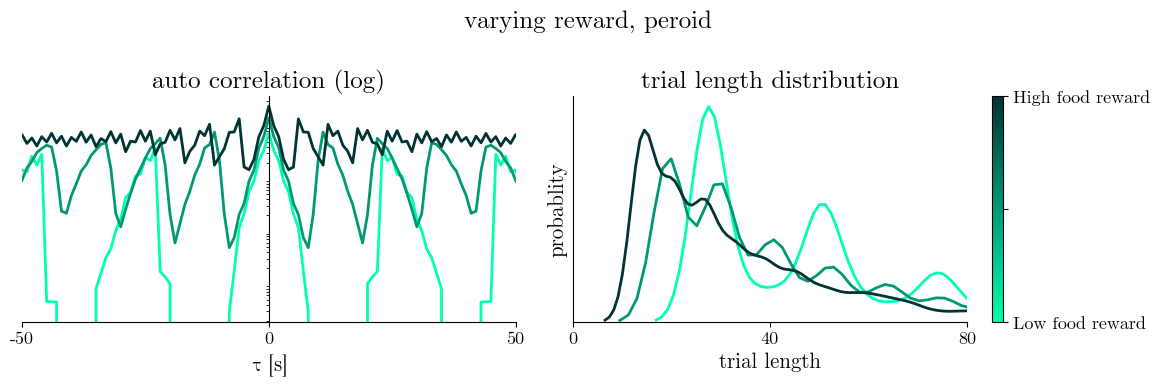

In [134]:
# autocorr
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

use_reward = [2, 3, 4]
# auto correlation
for i, food_reward_idx in enumerate(use_reward):
    att_seq_list = []
    for episode in all_episode_data:
        if episode['trial_food_reward_idx'] == food_reward_idx:
            att_seq_list.append([float(elt[1])
                                for elt in episode['actions']])
    # Sorting based on increasing trial length
    sorted_list_of_lists = sorted(att_seq_list, key=len)
    # Choosing what range of trial lengths to use. Could modify to be more consistent.
    sequences = sorted_list_of_lists[-plot_no_episodes:]
    # autocorr
    autocorr, total_counts = empirical_autocorrelation(
        sequences, min_no_samples=0)
    xs = np.arange(0, len(autocorr), 1)
    xs = xs-len(xs)//2
    ax1.plot(xs, autocorr,
             label=f'food reward={food_reward_list[food_reward_idx]:.0f}', color=cmap(np.linspace(0, 1, len(use_reward)))[i])
    # trial len dist
    sns.kdeplot([len(a) for a in att_seq_list],
                fill=False, bw_adjust=0.5, ax=ax2, color=cmap(np.linspace(0, 1, len(use_reward)))[i])

    ax1.set_xlabel(r'$\tau$ [s]')
    ax1.set_title('auto correlation (log)')
    ax1.set_xlim(-50, 50)
    # ax1.set_ylim(0, .03)
    ax1.set_xticks([-50, 0, 50])
    ax1.set_yscale('log')
    ax1.set_yticks([])
    ax1.spines['left'].set_position('zero')

    ax2.set_xlabel('trial length')
    ax2.set_ylabel('probablity')
    ax2.set_xlim(0, 80)
    ax2.set_xticks([0, 40, 80])
    ax2.set_yticks([])
    ax2.set_title('trial length distribution')

color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax2)
ticks = [0, 0.5, 1]
tick_labels = ['Low food reward', '', 'High food reward']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)


fig.suptitle('varying reward, peroid')
plt.tight_layout()
# quicksave('autocorr', modelname)
plt.show()

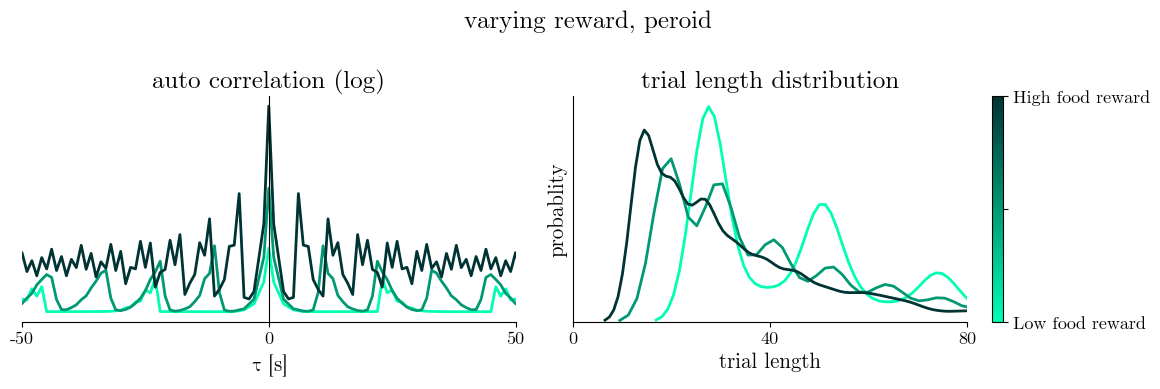

In [135]:
# autocorr
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

use_reward = [2, 3, 4]
# auto correlation
for i, food_reward_idx in enumerate(use_reward):
    att_seq_list = []
    for episode in all_episode_data:
        if episode['trial_food_reward_idx'] == food_reward_idx:
            att_seq_list.append([float(elt[1])
                                for elt in episode['actions']])
    # Sorting based on increasing trial length
    sorted_list_of_lists = sorted(att_seq_list, key=len)
    # Choosing what range of trial lengths to use. Could modify to be more consistent.
    sequences = sorted_list_of_lists[-plot_no_episodes:]
    # autocorr
    autocorr, total_counts = empirical_autocorrelation(
        sequences, min_no_samples=0)
    xs = np.arange(0, len(autocorr), 1)
    xs = xs-len(xs)//2
    ax1.plot(xs, autocorr,
             label=f'food reward={food_reward_list[food_reward_idx]:.0f}', color=cmap(np.linspace(0, 1, len(use_reward)))[i])
    # trial len dist
    sns.kdeplot([len(a) for a in att_seq_list],
                fill=False, bw_adjust=0.5, ax=ax2, color=cmap(np.linspace(0, 1, len(use_reward)))[i])

    ax1.set_xlabel(r'$\tau$ [s]')
    ax1.set_title('auto correlation (log)')
    ax1.set_xlim(-50, 50)
    # ax1.set_ylim(0, .03)
    ax1.set_xticks([-50, 0, 50])
    # ax1.set_yscale('log')
    ax1.set_yticks([])
    ax1.spines['left'].set_position('zero')

    ax2.set_xlabel('trial length')
    ax2.set_ylabel('probablity')
    ax2.set_xlim(0, 80)
    ax2.set_xticks([0, 40, 80])
    ax2.set_yticks([])
    ax2.set_title('trial length distribution')

color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax2)
ticks = [0, 0.5, 1]
tick_labels = ['Low food reward', '', 'High food reward']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)


fig.suptitle('varying reward, peroid')
plt.tight_layout()

plt.show()

webf NOT subset; don't know how to subset; dropped


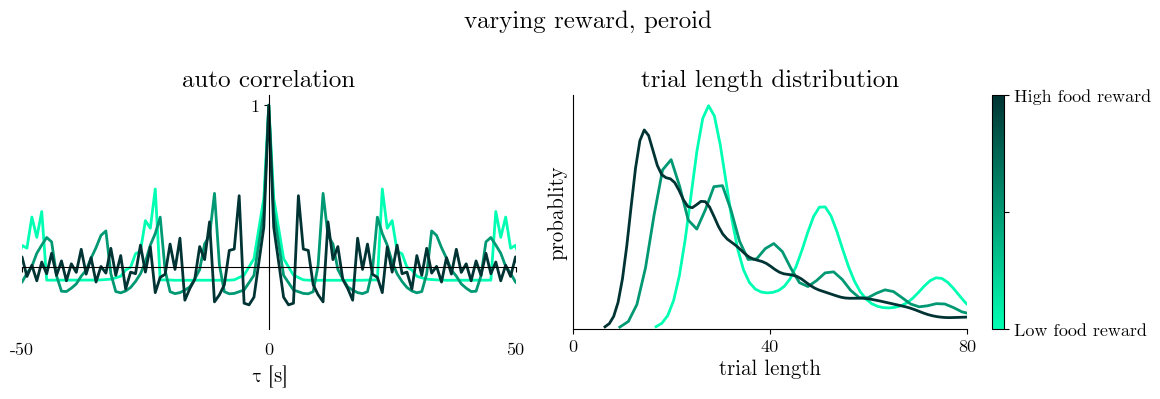

In [148]:
# autocorr
from ult import empirical_autocorrelation_new
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

use_reward = [2, 3, 4]
# auto correlation
for i, food_reward_idx in enumerate(use_reward):
    att_seq_list = []
    for episode in all_episode_data:
        if episode['trial_food_reward_idx'] == food_reward_idx:
            att_seq_list.append([float(elt[1])
                                for elt in episode['actions']])
    # Sorting based on increasing trial length
    sorted_list_of_lists = sorted(att_seq_list, key=len)
    # Choosing what range of trial lengths to use. Could modify to be more consistent.
    sequences = sorted_list_of_lists[-plot_no_episodes:]
    # autocorr
    autocorr, total_counts = empirical_autocorrelation_new(
        sequences, min_no_samples=0)
    xs = np.arange(0, len(autocorr), 1)
    xs = xs-len(xs)//2
    ax1.plot(xs, autocorr,
             label=f'food reward={food_reward_list[food_reward_idx]:.0f}', color=cmap(np.linspace(0, 1, len(use_reward)))[i])
    # trial len dist
    sns.kdeplot([len(a) for a in att_seq_list],
                fill=False, bw_adjust=0.5, ax=ax2, color=cmap(np.linspace(0, 1, len(use_reward)))[i])

    ax1.set_xlabel(r'$\tau$ [s]')
    ax1.set_title('auto correlation')
    ax1.set_xlim(-50, 50)
    # ax1.set_ylim(None, 1)
    ax1.set_xticks([-50, 0, 50])
    # ax1.set_yscale('log')
    ax1.set_yticks([1])
    ax1.spines['left'].set_position('zero')
    ax1.spines['bottom'].set_position('zero')
    ax1.tick_params(axis='x', pad=50) 

    ax2.set_xlabel('trial length')
    ax2.set_ylabel('probablity')
    ax2.set_xlim(0, 80)
    ax2.set_xticks([0, 40, 80])
    ax2.set_yticks([])
    ax2.set_title('trial length distribution')

color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax2)
ticks = [0, 0.5, 1]
tick_labels = ['Low food reward', '', 'High food reward']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)

fig.suptitle('varying reward, peroid')
quicksave('autocorr', 'plot p')
plt.tight_layout()


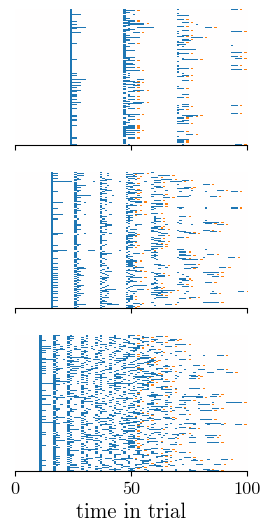

In [153]:
# heatmap trial indicator (att and lick) new, select len
minlen, maxlen = 50, 100
use_reward = [2, 3, 4]
fig, axs = plt.subplots(len(use_reward), 1, figsize=(
    3, len(use_reward)*2,), sharex=True, sharey=True)

for axi, food_reward_idx in enumerate(use_reward):
    attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
        food_reward_idx]
    trial_len = np.array(trial_len)
    valid_ind = np.where((minlen < trial_len) & (trial_len < maxlen))[0]
    grid = np.zeros((len(valid_ind), max(trial_len)+2))
    sortind = np.argsort([trial_len[i] for i in valid_ind])
    # valid_ind = valid_ind[sortind]

    # att
    plot_data = [att_time_list[i] for i in valid_ind]
    for i, arr in enumerate(plot_data):
        grid[i, arr] = -1

    # lick
    plot_data = [lick_time_list[i] for i in valid_ind]
    for i, arr in enumerate(plot_data):
        if arr:
            grid[i, arr] = 1
    if np.sum(grid) == 0:
        print(food_reward_idx)
        continue

    colors = [attn_color, 'white', lick_color]
    stops = [0.0, 0.5, 1.0]
    attnlickcmap = LinearSegmentedColormap.from_list(
        'custom_cmap', list(zip(stops, colors)))

    c = axs[axi].imshow(grid, cmap=attnlickcmap, vmin=-1, vmax=1,
                        aspect='auto', interpolation='none')

    plt.xticks([0, 50, 100])
    plt.xlim(0, 100)
    plt.ylim(0,300)
    plt.yticks([])
    ax = axs[axi]
    ax.spines['left'].set_visible(False)

plt.xlabel('time in trial')
# plt.ylabel('episode no. \n sorted by trial length')
# plt.title(f'attn, food reward: {food_reward_list[food_reward_idx]}')

# lickdot = Patch(color=lick_color, label='lick')
# attdot = Patch(color=attn_color, label='attention')
# extra_legend = plt.legend(
#     handles=[lickdot, attdot], bbox_to_anchor=(0, 1), frameon=True)
# ax.add_artist(extra_legend)


# quicksave(f'ep indicator {food_reward_idx}', modelname)

with plt.rc_context({'image.composite_image': False}):
    fig.savefig(f'fig/plot p/autocorr raster.svg')
plt.show()
